(PSL) Coding Assignment 2

Part II: Simulation Study

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as lm
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [46]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

Load Data

In [47]:
url = "https://raw.githubusercontent.com/liangfgithub/liangfgithub.github.io/master/Data/Coding2_Data2.csv"
myData = pd.read_csv(url)
# myData.head()
Y = myData['Y']
X = myData.drop(['Y'], axis = 1)

In [48]:
X.shape, len(Y)

((506, 91), 506)

Full Model

In [49]:
def full_model(X_train, Y_train, X_test, Y_test):
    #return 0
    full = lm().fit(X_train, Y_train)
    return mean_squared_error(Y_test, full.predict(X_test))

Ridge model

In [50]:
def ridge_model(X_train, Y_train, X_test, Y_test):
    #return 1
    ridge_alphas = np.logspace(-10, 1, 100)
    ridgecv = RidgeCV(alphas = ridge_alphas, cv = 10, 
                      scoring = 'neg_mean_squared_error', 
                      normalize = True)
    ridgecv.fit(X_train, Y_train)

    ridge_model = Ridge(alpha = ridgecv.alpha_, normalize = True)
    ridge_model.fit(X_train, Y_train)
    return mean_squared_error(Y_test, ridge_model.predict(X_test))

Lasso models

In [51]:
def lasso_models(X_train, Y_train, X_test, Y_test):
    #return 2, 3, 4
    lasso_alphas = np.logspace(-10, 1, 100)
    lassocv = LassoCV(alphas = lasso_alphas, cv = 10, 
                      normalize = True)
    lassocv.fit(X_train, Y_train)
    lassocv.alpha_

    mean_mse = np.mean(lassocv.mse_path_, axis=1)
    std_mse = np.std(lassocv.mse_path_, axis=1) / np.sqrt(10) 

    cv_alphas = lassocv.alphas_
    min_idx = np.argmin(mean_mse)

    alpha_min = cv_alphas[min_idx]

    threshold = mean_mse[min_idx] + std_mse[min_idx]
    alpha_1se = max(cv_alphas[np.where(mean_mse <= threshold)])

    alpha_min, alpha_1se  #alpha_min = lassocv.alpha_

    lasso_model_min = Lasso(alpha = alpha_min, normalize = True, max_iter=10000)
    lasso_model_min.fit(X_train, Y_train)
    
    lasso_model_1se = Lasso(alpha = alpha_1se, normalize = True, max_iter=10000)
    lasso_model_1se.fit(X_train, Y_train)
    
    nonzero_indices = np.where(lasso_model_1se.coef_ != 0)[0]
    lm_refit = lm()
    lm_refit.fit(X_train.iloc[:, nonzero_indices], Y_train)
    
    lasso_min = mean_squared_error(Y_test, lasso_model_min.predict(X_test))
    lasso_1se = mean_squared_error(Y_test, lasso_model_1se.predict(X_test))
    lasso_refit = mean_squared_error(Y_test, lm_refit.predict(X_test.iloc[:, nonzero_indices]))
    return lasso_min, lasso_1se, lasso_refit

In [52]:
class PCR(object):

    def __init__(self, num_folds=10):
        self.folds = num_folds

    def fit(self, X, Y):
        n, p = X.shape
        indices = np.arange(n)
        np.random.shuffle(indices)
        index_sets = np.array_split(indices, self.folds)
        ncomp = min(p, n - 1 - max([len(i) for i in index_sets]))
        cv_err = np.zeros(ncomp)

        for ifold in range(self.folds):
            train_inds =  np.delete(index_sets, obj=ifold, axis=0).ravel()
            test_inds = index_sets[ifold]

            X_train = X[train_inds, :]
            pipeline = Pipeline([('scaling', StandardScaler()), ('pca', PCA())])
            pipeline.fit(X_train)
            X_train = pipeline.transform(X_train)
            coefs = Y[train_inds].T @ X_train / np.sum(X_train**2, axis=0)
            b0 = np.mean(Y[train_inds])

            X_test = pipeline.transform(X[test_inds, :])

            for k in np.arange(ncomp):
                preds = X_test[:, :k] @ coefs.T[:k] + b0
                cv_err[k] += cv_err[k] + np.sum((Y[test_inds]-preds)**2)

        min_ind = np.argmin(cv_err)
        self.ncomp = min_ind+1
        pipeline = Pipeline([('scaling', StandardScaler()), ('pca', PCA(n_components=self.ncomp))])
        self.transform = pipeline.fit(X)
        self.model = lm().fit(self.transform.transform(X), Y)

    def predict(self, X):
        X_ = self.transform.transform(X)
        return self.model.predict(X_)

def PCR_model(X_train, Y_train, X_test, Y_test):
    pcr = PCR()
    pcr.fit(np.array(X_train), np.array(Y_train))
    return mean_squared_error(np.array(Y_test), pcr.predict(np.array(X_test)))

In [53]:
n = len(Y)
indices = np.arange(0, n)
mses_wFull = []

for i in range(50):
    np.random.shuffle(indices)
    test_ind = indices[:int(np.floor(0.25*n))]
    train_ind = indices[len(test_ind):]

    # Splitting the data into training and testing sets
    X_train = X.iloc[train_ind]
    Y_train = Y[train_ind]
    X_test = X.iloc[test_ind]
    Y_test = Y[test_ind]

    #Run all 6 procedures
    results_full = full_model(X_train, Y_train, X_test, Y_test)
    results_ridge = ridge_model(X_train, Y_train, X_test, Y_test)
    results_lambda_min, results_lambda_1se, results_lambda_refit = lasso_models(X_train, Y_train, X_test, Y_test)
    results_PCR = PCR_model(X_train, Y_train, X_test, Y_test)
    if i%5 == 0:
        print(i)

    mses_wFull.append([results_full, results_ridge, results_lambda_min, results_lambda_1se, results_lambda_refit, results_PCR])

0
5
10
15
20
25
30
35
40
45


In [54]:
mses_wFull_data = pd.DataFrame(mses_wFull)
mses_wFull_data.describe()

,0,1,2,3,4,5
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.029167,0.026058,0.026615,0.029360,0.029402,0.028415
std,0.005913,0.004989,0.005104,0.005600,0.006091,0.005709
min,0.020830,0.017302,0.017893,0.019072,0.017161,0.017958
25%,0.024651,0.022000,0.022123,0.024472,0.024664,0.024286
50%,0.028388,0.025288,0.025614,0.028552,0.029328,0.027921
75%,0.031707,0.029884,0.029723,0.032678,0.032775,0.031496
max,0.045768,0.038264,0.040091,0.041451,0.043559,0.044850


([<matplotlib.axis.XTick at 0x1e45e22c6a0>,
 <a list of 6 Text xticklabel objects>)

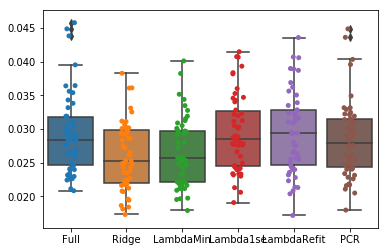

In [64]:
sns.boxplot(data=mses_wFull_data, saturation=0.5)
sns.stripplot(data=mses_wFull_data)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Full" ,"Ridge", "LambdaMin", "Lambda1se", "LambdaRefit", "PCR"])

It seems like Ridge model has the best performance with MSPE of 0.026

Conversely, the Lambda Refitting has the worst performance with MSPE of 0.0294

Lasso.min yields a better MSPE than Lasso.1se

Refitting is not advantageous in this case, L.Refit not does outperform Lasso.1se

Both variable selection or shrinkage are warranted for this particular dataset. In terms of MSPE, performance of the Full model to be worse than the best-performing procedure

In [56]:
url = "https://raw.githubusercontent.com/liangfgithub/liangfgithub.github.io/master/Data/Coding2_Data3.csv"
myData = pd.read_csv(url)
B = myData['Y']
A = myData.drop(['Y'], axis = 1)


In [57]:
A.shape, len(B)

((506, 591), 506)

In [58]:
n = len(B)
indices = np.arange(0, n)
mses = []

for i in range(50):
    np.random.shuffle(indices)
    test_ind = indices[:int(np.floor(0.25*n))]
    train_ind = indices[len(test_ind):]

    # Splitting the data into training and testing sets
    A_train = A.iloc[train_ind]
    B_train = B[train_ind]232
    +
    A_test = A.iloc[test_ind]
    B_test = B[test_ind]

    #Run 5 procedures except full model
    results_ridge = ridge_model(A_train, B_train, A_test, B_test)
    results_lambda_min, results_lambda_1se, results_lambda_refit = lasso_models(A_train, B_train, A_test, B_test)
    results_PCR = PCR_model(A_train, B_train, A_test, B_test)
    if i%5 == 0:
        print(i)

    mses.append([results_ridge, results_lambda_min, results_lambda_1se, results_lambda_refit, results_PCR])

0
5
10
15
20
25
30
35
40
45


In [59]:
mses_data = pd.DataFrame(mses)
mses_data.describe()

,0,1,2,3,4
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.052371,0.042363,0.046549,0.044061,0.056856
std,0.007840,0.006941,0.008241,0.007840,0.009223
min,0.037315,0.026379,0.030689,0.025945,0.036710
25%,0.046945,0.037658,0.041182,0.037882,0.051436
50%,0.053712,0.041680,0.045711,0.043134,0.056356
75%,0.056756,0.047848,0.052153,0.048977,0.062635
max,0.071162,0.057982,0.066010,0.063756,0.073925


([<matplotlib.axis.XTick at 0x1e45e18aa90>,
 <a list of 5 Text xticklabel objects>)

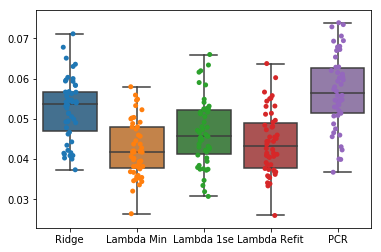

In [63]:
sns.boxplot(data=mses_data, saturation=0.5)
sns.stripplot(data=mses_data)
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=["Ridge", "Lambda Min", "Lambda 1se", "Lambda Refit", "PCR"])

Which procedure or procedures yield the best performance in terms of MSPE?

Conversely, which procedure or procedures show the poorest performance?

Have you observed any procedure or procedures that performed well in Case I but exhibited poorer performance in Case II, 
or vice versa? If so, please offer an explanation.

Given that Coding2_Data3.csv includes all features found in Coding2_Data2.csv, one might anticipate that the best MSPE
in Case II would be equal to or lower than the best MSPE in Case I. 

Do your simulation results corroborate this expectation? If not, please offer an explanation.

The Lamda min seems to have the best performance with MSPE of 0.042 with the Lamda refit being the close second best with MSPE of 0.044.

Conversely, in this case the PCR has the worst performance with MSPE of 0.057.

In case 2, all the results are worse than case 1. However, Lambda Refit is one of the best (second lowest MSPE) procedures in case 2, while it was the worst performing procedure for case 1. The refit parameter is used to indicate whether the regularization parameter should be re-estimated after fitting the model. This can be useful when there is noise present in the data which is exactly what we observe.

Here, in case 2 the best MSPE is actually worse than the best MSPE seen for case 1. In case 2, we add 500 noise columns to a signal of 92 colummns. In presence of huge amounts of noise, regularization is not expected to perform better. Small amounts of noise can be tolerated by the model but in case, it seems like the amount of noise is too high for the model to handle. 